In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def basic_exploration(df):
    print("First 5 rows:")
    display(df.head())

    print("\nShape of dataset:")
    print(df.shape)

    print("\nDataset information:")
    df.info()

    print("\nStatistical summary:")
    display(df.describe(include="all"))

    print("\nMissing values:")
    display(df.isnull().sum())

In [3]:
tips = sns.load_dataset("tips")
basic_exploration(tips)

First 5 rows:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



Shape of dataset:
(244, 7)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

Statistical summary:


,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000



Missing values:


total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## Find Average Total Bill and Average Tip

In [4]:
print("Average total bill:", tips["total_bill"].mean())
print("Average tip:", tips["tip"].mean())

Average total bill: 19.78594262295082
Average tip: 2.99827868852459


## Analyze Whether Higher Bills Lead to Higher Tips

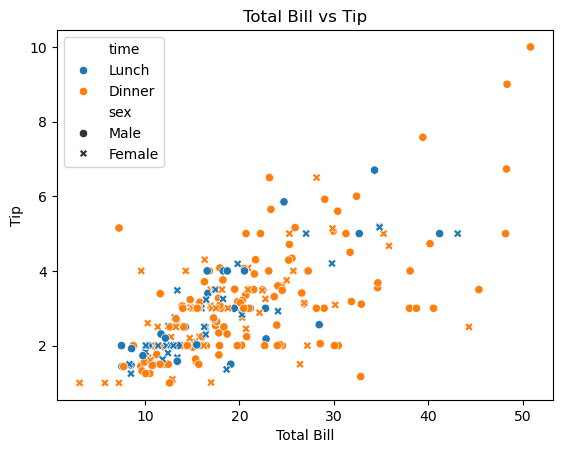

Correlation between total bill and tip:
            total_bill       tip
total_bill    1.000000  0.675734
tip           0.675734  1.000000


In [5]:
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time", style="sex")
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

print("Correlation between total bill and tip:")
print(tips[["total_bill", "tip"]].corr())

## Observation
## There is a positive relationship between total bill and tip. In general, customers with higher bills tend to give higher tips.

## Compare Total Bill on Different Days

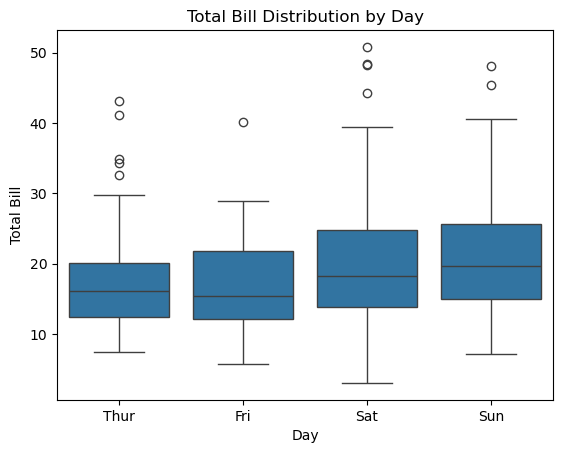

Average total bill by day:
day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64


In [6]:
sns.boxplot(data=tips, x="day", y="total_bill")
plt.title("Total Bill Distribution by Day")
plt.xlabel("Day")
plt.ylabel("Total Bill")
plt.show()

print("Average total bill by day:")
print(tips.groupby("day", observed=True)["total_bill"].mean())

### Observation: Weekend days generally show higher total bills. The boxplot also shows outliers where some customers spent much more than usual.Dinner customers usually give higher tips than lunch customers. This may happen because dinner bills are often larger.

## Compare Tips During Lunch and Dinner

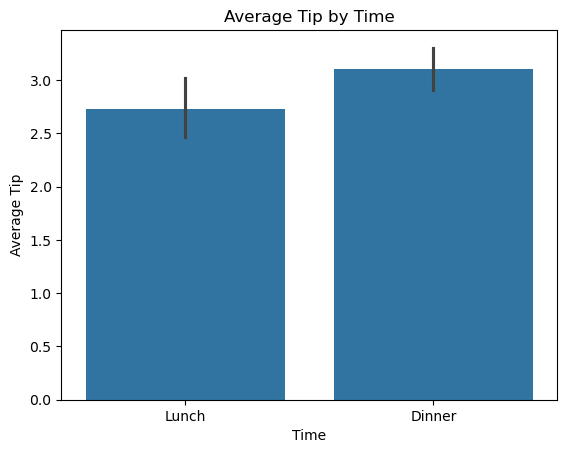

Average tip by time:
time
Lunch     2.728088
Dinner    3.102670
Name: tip, dtype: float64


In [7]:
sns.barplot(data=tips, x="time", y="tip")
plt.title("Average Tip by Time")
plt.xlabel("Time")`
plt.ylabel("Average Tip")
plt.show()

print("Average tip by time:")
print(tips.groupby("time", observed=True)["tip"].mean())

## Compare Tips Based on Smoker and Non-Smoker Customers

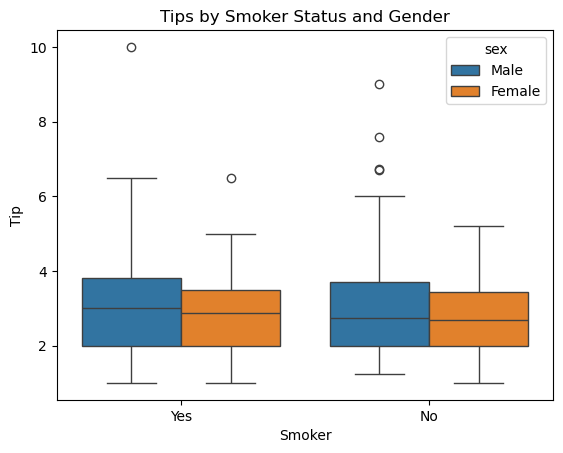

In [9]:
sns.boxplot(data=tips, x="smoker", y="tip", hue="sex")
plt.title("Tips by Smoker Status and Gender")
plt.xlabel("Smoker")
plt.ylabel("Tip")
plt.show()